In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick, Sphere, Cylinder, SandiB, SandiW
from dmri.simulators.acquisition_scheme import acquisition_scheme
from dmri.simulators.local_signal_models.distributional_models import WatsonStick, WatsonZeppelin,BinghamStick, BinghamZeppelin, NoddiW, NoddiB


In [5]:
bvals = jnp.linspace(0, 3000, 100)
bvecs = np.random.randn(100, 3)
bvecs = bvecs / np.linalg.norm(bvecs, axis=1)[:, None]

acq = acquisition_scheme(bvals, bvecs)


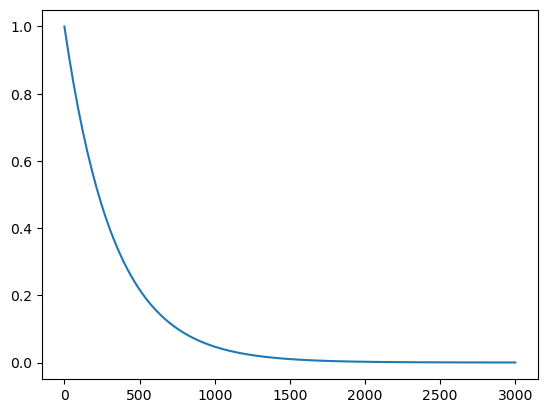

In [6]:
theta = np.random.randn(Ball.theta_dim)
ball = Ball.from_theta(theta)


signal = ball.signal(acq)

plt.plot(bvals, signal)

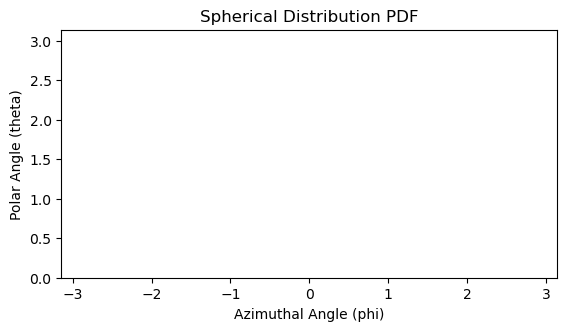

In [7]:

%matplotlib inline
ball.to_fod().viz()

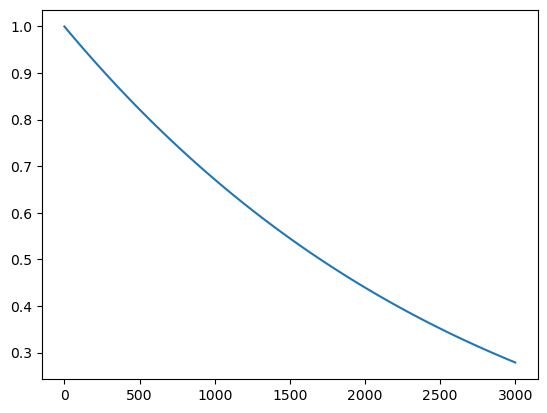

In [8]:
theta = np.random.randn(Sphere.theta_dim)
ball = Sphere.from_theta(theta)


signal = ball.signal(acq)

plt.plot(bvals, signal)

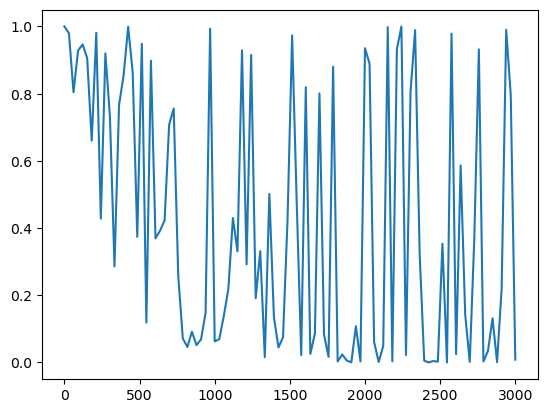

In [61]:
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)


signal = stick.signal(acq)

plt.plot(bvals, signal)

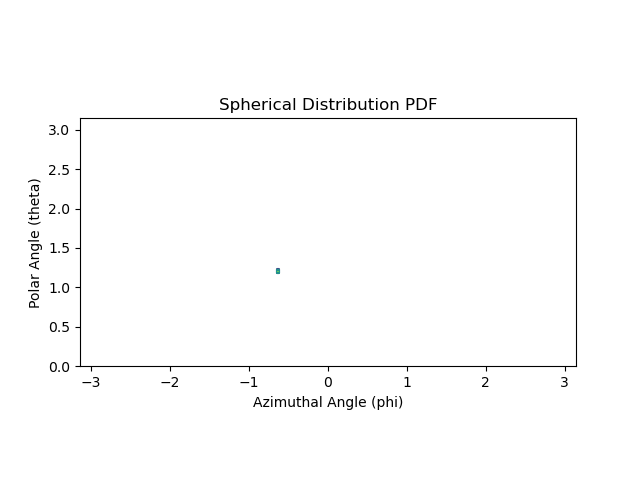

In [67]:
%matplotlib widget
stick.to_fod().viz(plot_type='polar')

In [68]:
theta = np.random.randn(Cylinder.theta_dim)
stick = Cylinder.from_theta(theta)


signal = stick.signal(acq)

plt.plot(bvals, signal)

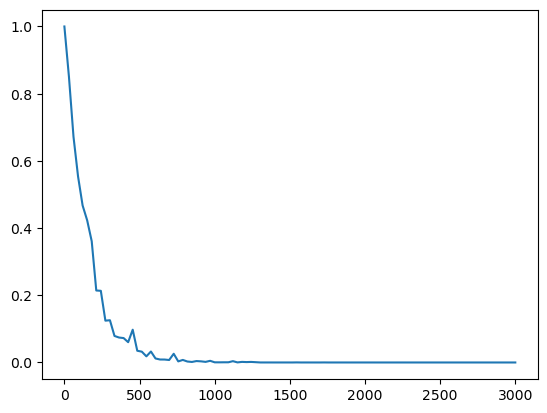

In [93]:
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)


signal = zep.signal(acq)

plt.plot(bvals, signal)

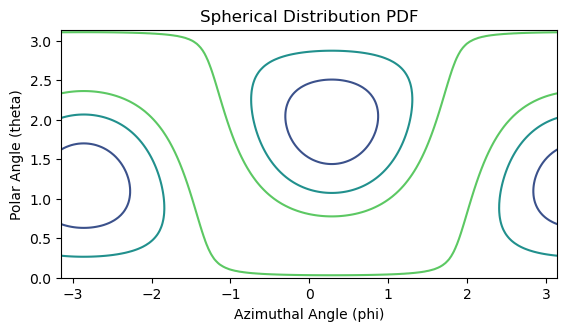

In [94]:
%matplotlib inline
zep.to_fod().viz()

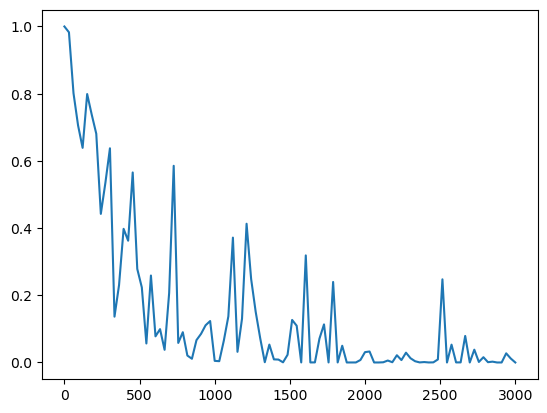

In [14]:
theta = np.random.randn(Dti.theta_dim)
dti = Dti.from_theta(theta)


signal = dti.signal(acq)

plt.plot(bvals, signal)

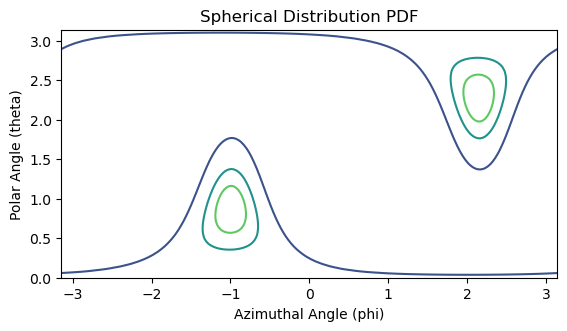

In [15]:
%matplotlib inline
dti.to_fod().viz()

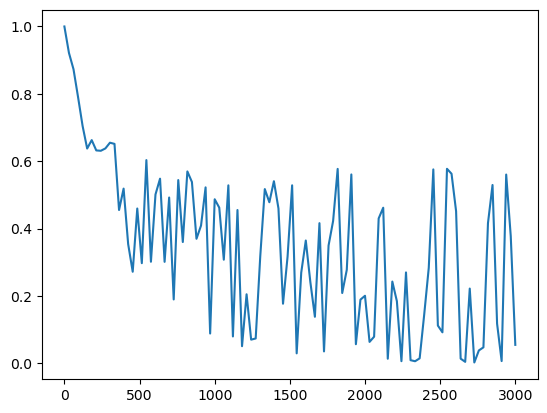

In [16]:
ball_stick = BallStick.from_theta(np.random.randn(BallStick.theta_dim))

signal = ball_stick.signal(acq, None)

plt.plot(bvals, signal)

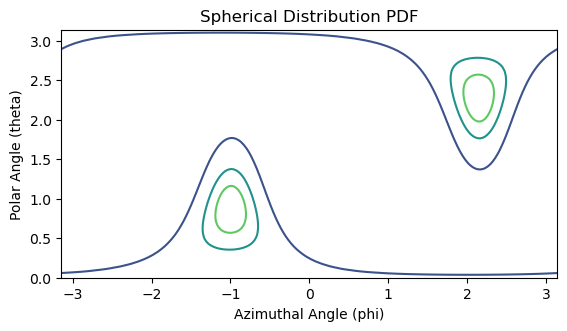

In [17]:
%matplotlib inline
dti.to_fod().viz()

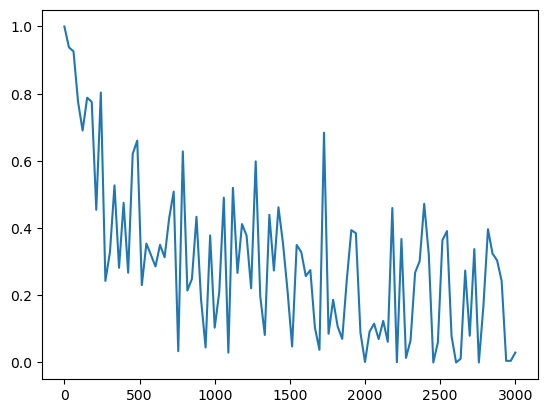

In [18]:
ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

signal = ball_stick.signal(acq, None)

plt.plot(bvals, signal)

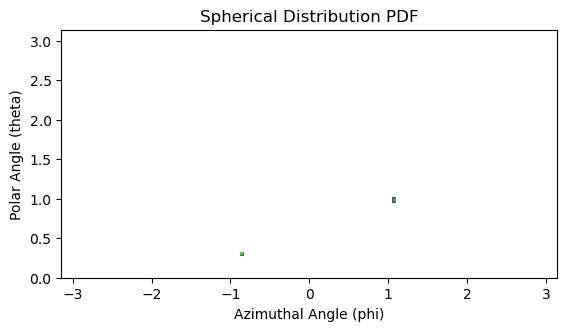

In [19]:
%matplotlib inline
ball_stick.to_fod().viz()

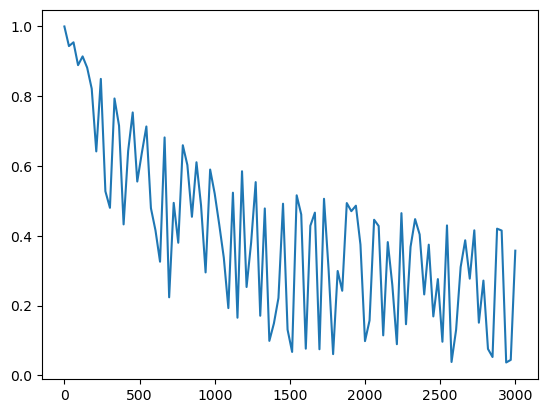

In [20]:
racket = WatsonStick.from_theta(np.random.randn(WatsonStick.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

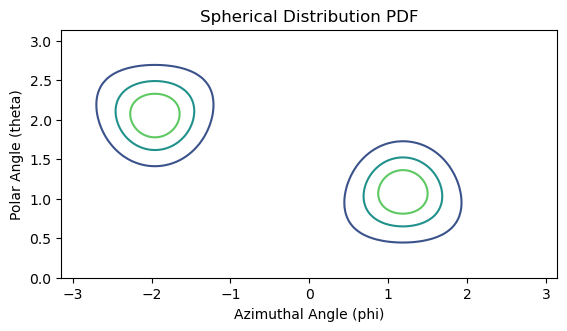

In [21]:
%matplotlib inline
racket.to_fod().viz()

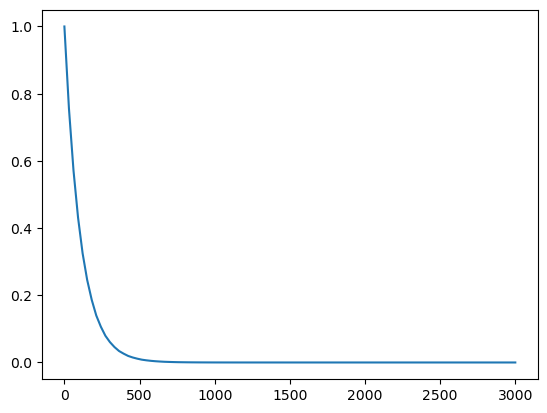

In [22]:
racket2 = WatsonZeppelin.from_theta(np.random.randn(WatsonZeppelin.theta_dim))
signal = racket2.signal(acq)
plt.plot(bvals, signal)

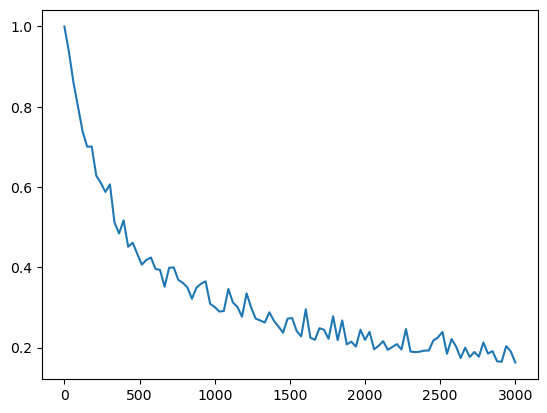

In [23]:
bracket = BinghamStick.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = bracket.signal(acq)
plt.plot(bvals, signal)

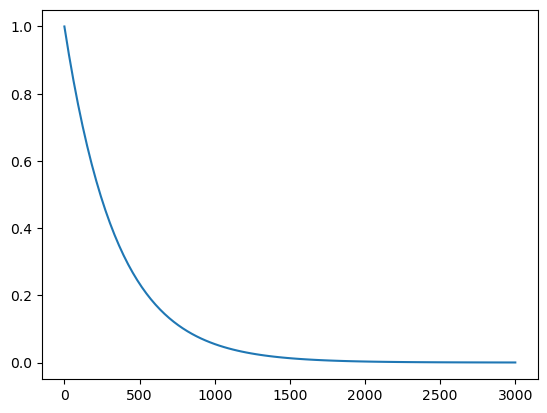

In [24]:
racket = BinghamZeppelin.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

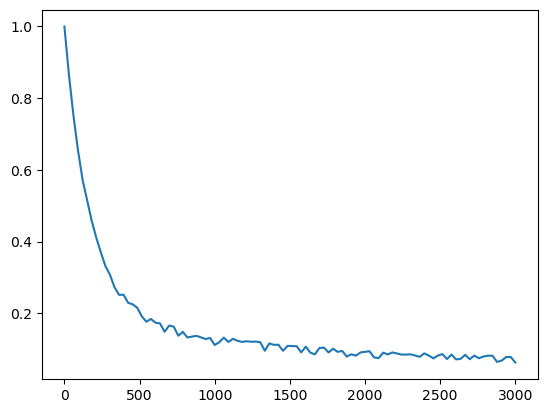

In [25]:
racket = NoddiW.from_theta(np.random.randn(NoddiW.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

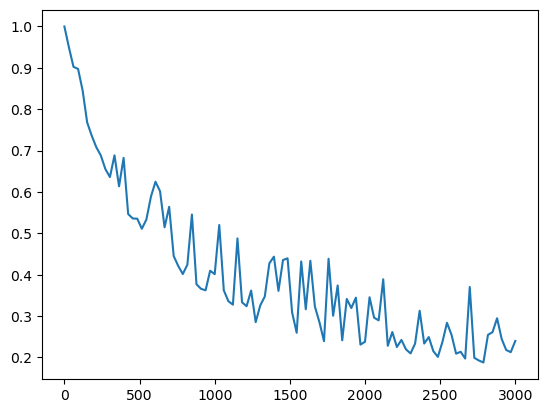

In [26]:
racket = NoddiB.from_theta(np.random.randn(NoddiB.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

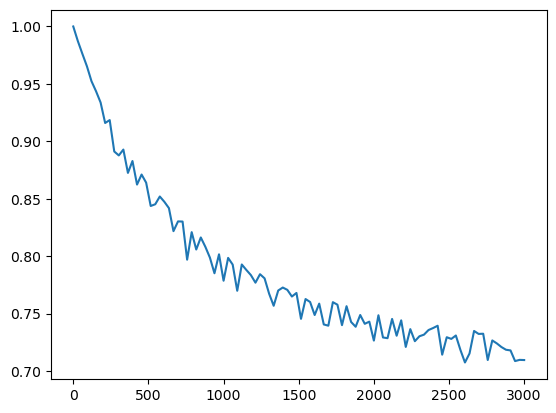

In [27]:
racket = SandiW.from_theta(np.random.randn(SandiW.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

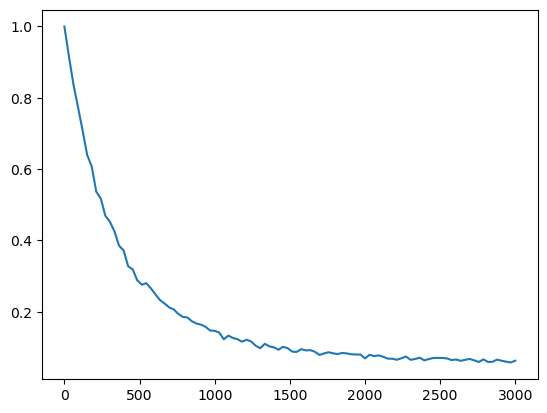

In [28]:
racket = SandiB.from_theta(np.random.randn(SandiB.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

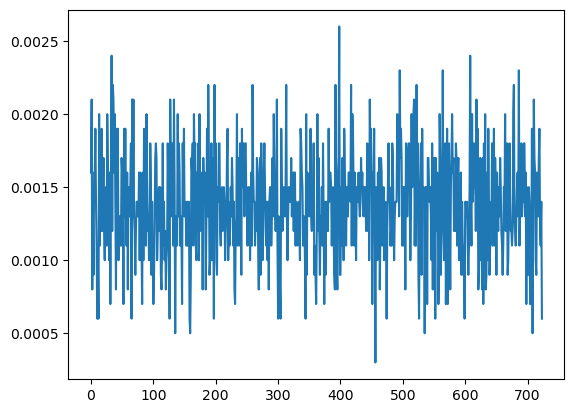

In [29]:
from dmri.simulators.sphereical_distributions import Uniform
import matplotlib.pyplot as plt

plt.plot(Uniform().to_pmf(n_samples=10_000))

In [30]:
signal = racket.signal(acq)

In [31]:
%%timeit
racket.signal(acq).block_until_ready()

257 ms ± 6.41 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [32]:
sim_jit = jax.jit(racket.signal)

In [33]:
%%timeit
sim_jit(acq).block_until_ready()

16.3 ms ± 377 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [34]:
from dmri.utils.transform import normal_to_dirichlet, dirichlet_to_normal
import numpy as np
import jax.numpy as jnp

import jax


jax.grad(lambda x:normal_to_dirichlet(x,y).sum(), argnums=1)(jnp.ones(3)*2, jnp.ones(2))

TypeError: <lambda>() takes 1 positional argument but 2 were given

In [41]:
(normal_to_dirichlet(jnp.ones(2), jnp.ones(1))[0] - normal_to_dirichlet(jnp.ones(2), jnp.ones(1) + 0.0001)[0])/0.0001

Array(-0.24199486, dtype=float32)

In [75]:
_f = lambda x: normal_to_dirichlet(jnp.ones(2)*10, x)[0]

jax.grad(_f)(jnp.ones(1))

(2, 1) (2,)


Array([0.10891537], dtype=float32)

In [76]:
(_f(jnp.ones(1) + 0.0001) - _f(jnp.ones(1)))/0.0001

Array(0.10848045, dtype=float32)

In [69]:
_f = lambda x: normal_to_dirichlet(jnp.ones(2)*10, x)[0]
_f(jnp.ones(1)*0.1)

Array(0.5113202, dtype=float32)

In [26]:
normal_to_dirichlet(jnp.ones(2)*10, jnp.ones(1)*0.5)

Array([0.5564234 , 0.44357657], dtype=float32)

In [26]:
jax.grad(lambda x,y: dirichlet_to_normal(x,y).mean(), argnums=1)(jnp.ones(3), jnp.ones(3)/3)

Array([2.6274624, 1.8799714, 0.       ], dtype=float32)

In [48]:
J = jax.jacfwd(lambda x: dirichlet_to_normal(jnp.ones(3), x, mask=jnp.array([True,True, False])))(jnp.ones(3)/3)

In [49]:
jnp.linalg.pinv(J).shape

(3, 2)

In [50]:
(jnp.linalg.pinv(J)@jnp.eye(2))

Array([[0.3635998, 0.       ],
       [0.       , 0.       ],
       [0.       , 0.       ]], dtype=float32)

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from dmri.utils.transform import normal_to_psd, psd_to_normal, s3_to_r3, r3_to_s3
import jax

In [14]:
eps = jax.random.normal(jax.random.PRNGKey(3), (6,))

In [15]:
eps

Array([-1.446257  ,  1.539381  ,  0.38250625,  1.9707018 , -0.5876674 ,
        0.20941563], dtype=float32)

In [16]:
Q, sort_idx = normal_to_psd(eps)

0.99999994


In [17]:
Q

Array([[ 0.29037553,  0.20636077,  0.13140655],
       [ 0.20636077,  0.59197617, -0.00267761],
       [ 0.13140655, -0.0026776 ,  0.9126866 ]], dtype=float32)

In [18]:
jax.numpy.linalg.eigh(Q)

EighResult(eigenvalues=Array([0.1666473 , 0.68406105, 0.94432974], dtype=float32), eigenvectors=Array([[ 0.8880106 ,  0.39545837,  0.23462683],
       [-0.4318388 ,  0.8925195 ,  0.13009186],
       [-0.15796311, -0.2168439 ,  0.96334124]], dtype=float32))

In [19]:
eps_rec = psd_to_normal(Q, sort_idx)

In [20]:
eps_rec

Array([-1.4462566 ,  1.5393792 ,  0.38250533,  0.01578912,  0.12338073,
       -0.14858298], dtype=float32)

In [22]:
eps

Array([-1.446257  ,  1.539381  ,  0.38250625,  1.9707018 , -0.5876674 ,
        0.20941563], dtype=float32)